# Neural Network-Based Stock Return Forecasting with Simulated Backtesting
**CSCI 357 - AI and Neural Networks | Spring 2026**  
**Author:** Sophie Yang 
---

## Project Overview

This project builds a stock return forecasting system using LSTM (Long Short-Term Memory) and Transformer neural networks.
I apply the models to four assets from different industries, translate predictions into trading signals, and evaluate portfolio performance through a simulated backtesting framework.

**Assets:**
- `TSLA` — Tesla: Technology / Electric Vehicles
- `JPM` — JPMorgan Chase: Financial
- `XOM` — Exxon Mobil: Energy
- `SPY` — S&P 500 Index ETF (market benchmark)

**Workflow:**
1. Data Collection & Feature Engineering
2. Sliding Window Dataset Construction
3. Train / Validation / Test Split
4. LSTM Model — Training & Evaluation
5. Transformer Model — Training & Evaluation
6. Model Comparison
7. Backtesting & Portfolio Simulation

---
## Section 1: Data Collection & Feature Engineering

I pull historical daily OHLCV data using `yfinance` from 2020-01-01 to present.

**Features computed per asset:**
- **Daily Return**: `pct_change()` of closing price — stationary and suitable for sequence modeling
- **MA5**: 5-day rolling mean of close — captures short-term trend
- **MA20**: 20-day rolling mean of close — captures medium-term trend
- **RSI (14-day)**: Relative Strength Index — measures whether a stock is overbought (>70) or oversold (<30), a classic momentum indicator in technical analysis.

I use four assets from different industries so the model sees diverse market behaviors, making the comparison more meaningful (as advised).

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

I only extract the closing price from the raw data below, as it is the standard reference point for computing daily returns and moving averages.

In [23]:
# Download data for 4 assets from different industries
TICKERS = ["TSLA", "JPM", "XOM", "SPY"]
START_DATE = "2020-01-01"

raw = yf.download(TICKERS, start=START_DATE)
close = raw["Close"]

print(f"Data shape: {close.shape}")
print(f"Date range: {close.index[0].date()} to {close.index[-1].date()}")
close.head()

[*********************100%***********************]  4 of 4 completed

Data shape: (1591, 4)
Date range: 2020-01-02 to 2026-05-01


Ticker,JPM,SPY,TSLA,XOM
Date,,,,
2020-01-02,118.430313,296.888214,28.684000,53.306419
2020-01-03,116.867462,294.639984,29.534000,52.877865
2020-01-06,116.774536,295.764160,30.102667,53.283852
2020-01-07,114.789307,294.932495,31.270666,52.847775
2020-01-08,115.684776,296.504333,32.809334,52.050808


In [24]:
# Compute features for each asset

# daily return 
returns = close.pct_change()          
# 5-day moving average
ma5    = close.rolling(5).mean()     
# 20-day moving average
ma20   = close.rolling(20).mean()     

# Drop rows with NaN (first 20 rows due to rolling window)
returns = returns.dropna()
ma5     = ma5.loc[returns.index]
ma20    = ma20.loc[returns.index]
close_aligned = close.loc[returns.index]

# RSI (14-day Relative Strength Index)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = -delta.clip(upper=0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

rsi = close.apply(compute_rsi)
rsi = rsi.loc[returns.index]

print(f"Features shape after dropping NaN: {returns.shape}")
returns.head()

Features shape after dropping NaN: (1590, 4)


Ticker,JPM,SPY,TSLA,XOM
Date,,,,
2020-01-03,-0.013196,-0.007573,0.029633,-0.008039
2020-01-06,-0.000795,0.003815,0.019255,0.007678
2020-01-07,-0.017001,-0.002812,0.038801,-0.008184
2020-01-08,0.007801,0.005329,0.049205,-0.015080
2020-01-09,0.003651,0.006781,-0.021945,0.007656


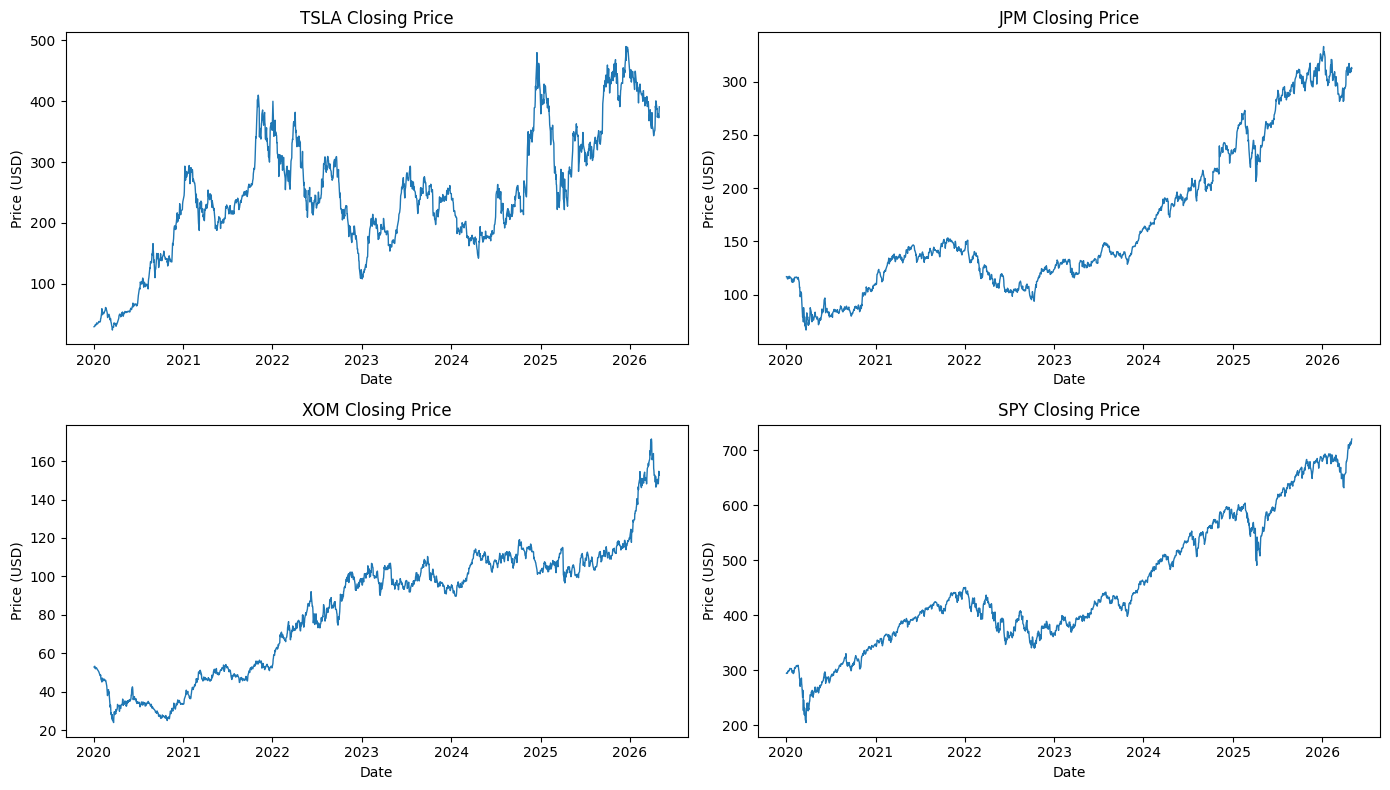

In [25]:
# Visualize closing prices for all 4 assets
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    axes[i].plot(close_aligned[ticker], linewidth=1)
    axes[i].set_title(f"{ticker} Closing Price")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price (USD)")

plt.tight_layout()
plt.savefig("closing_prices.png", dpi=100)
plt.show()

---
## Section 2: Sliding Window Dataset Construction

I reshape the time series into supervised learning format.

**Sliding window logic:**
- Input (X): past `WINDOW` days of [return, MA5, MA20] for all 4 assets
- Label (y): next day's return for each asset

For example with WINDOW=20:
- X[0] = days 0–19, y[0] = day 20
- X[1] = days 1–20, y[1] = day 21
- ... and so on

In [ ]:
WINDOW = 20  # look-back period: use past 20 days to predict next day

def make_sequences(returns_df, ma5_df, ma20_df, rsi_df, window=20):
    """
    Build sliding window sequences.
    Each sample: (window x num_features) -> next day return for all tickers.
    Features per ticker: [return, ma5_normalized, ma20_normalized, rsi]
    """
    n = len(returns_df)
    num_tickers = len(returns_df.columns)
    
    # Stack features: shape (n_days, num_tickers * 3)
    features = np.concatenate([
        returns_df.values,
        ma5_df.pct_change().fillna(0).values,
        ma20_df.pct_change().fillna(0).values,
        rsi_df.fillna(50).values          # RSI, default 50 when missing
    ], axis=1)
    
    X, y = [], []
    for i in range(n - window):
        X.append(features[i : i + window])       # past 20 days
        y.append(returns_df.values[i + window])  # next day return
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = make_sequences(returns, ma5, ma20, rsi, window=WINDOW)

print(f"X shape: {X.shape}  → (samples, window, features)")
print(f"y shape: {y.shape}  → (samples, num_tickers)")

X shape: (1570, 20, 16)  → (samples, window, features)
y shape: (1570, 4)  → (samples, num_tickers)


---
## Section 3: Train / Validation / Test Split

**Important:** For time series data, I NEVER shuffle randomly.
I split strictly by time to avoid look-ahead bias (using future data to predict the past).

- **Train**: 2020 – 2023 (model learns from this)
- **Validation**: 2023 – 2024 (used to tune hyperparameters)
- **Test**: 2024 – present (never seen during training, used for backtesting later)

In [27]:
# Total samples after sliding window
n_samples = len(X)

# Approximate date-based splits (80% train, 10% val, 10% test)
train_end = int(n_samples * 0.75)
val_end   = int(n_samples * 0.875)

X_train, y_train = X[:train_end],         y[:train_end]
X_val,   y_val   = X[train_end:val_end],  y[train_end:val_end]
X_test,  y_test  = X[val_end:],           y[val_end:]

print(f"Train samples:      {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")

Train samples:      1177
Validation samples: 196
Test samples:       197


In [28]:
# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_val_t   = torch.tensor(X_val)
y_val_t   = torch.tensor(y_val)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    list(zip(X_train_t, y_train_t)), batch_size=BATCH_SIZE, shuffle=False
)
val_loader = DataLoader(
    list(zip(X_val_t, y_val_t)), batch_size=BATCH_SIZE, shuffle=False
)

print("DataLoaders ready.")

DataLoaders ready.


---
## Section 4: LSTM Model — Training & Evaluation

**Why LSTM?**  
Stock returns are sequential data with temporal dependencies. LSTM (Long Short-Term Memory) is designed for exactly this that it reads data step by step and uses gates (forget, input, output) to decide what information to remember across time. This makes it well-suited for capturing short-term momentum patterns in financial time series.

**Architecture:**
- Input: (batch, window=20, features=12)
- LSTM layers with hidden size
- Fully connected output layer → predicted return for each asset

At each timestep, four operations happen:

| Gate | Question it asks | What it does |
|------|-----------------|--------------|
| Forget gate | What should I forget? | Erases irrelevant past memory |
| Input gate | What new info matters? | Decides what today's data to store |
| Memory update | What do I remember now? | Combines old memory + new info |
| Output gate | What do I output? | Passes relevant memory to next step |

The final timestep's output is passed to a fully connected layer to produce the prediction.

In [29]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        # Take the last timestep output
        return self.fc(out[:, -1, :])


INPUT_SIZE  = X_train.shape[2]   # number of features
OUTPUT_SIZE = y_train.shape[1]   # number of tickers
HIDDEN_SIZE = 64
NUM_LAYERS  = 2

lstm_model = LSTMForecaster(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
print(lstm_model)
print(f"\nTotal parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTMForecaster(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

Total parameters: 54,532


In [30]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                val_loss += criterion(pred, yb).item()
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    return train_losses, val_losses


print("Training LSTM...")
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, val_loader, epochs=50, lr=1e-3
)

Training LSTM...
Epoch  10 | Train Loss: 0.000713 | Val Loss: 0.000715
Epoch  20 | Train Loss: 0.000685 | Val Loss: 0.000865
Epoch  30 | Train Loss: 0.000674 | Val Loss: 0.000941
Epoch  40 | Train Loss: 0.000665 | Val Loss: 0.000804
Epoch  50 | Train Loss: 0.000687 | Val Loss: 0.000870


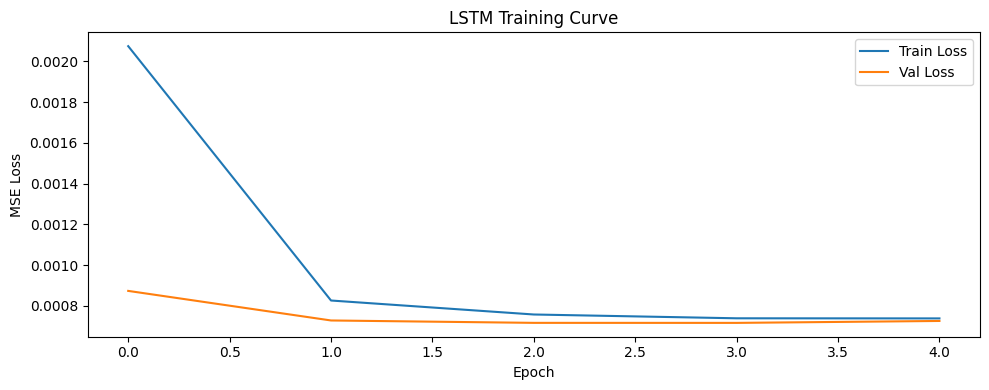

In [31]:
# Plot LSTM training curves
plt.figure(figsize=(10, 4))
plt.plot(lstm_train_losses[:5], label="Train Loss")
plt.plot(lstm_val_losses[:5],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=100)
plt.show()

probably look at more detailed from 0 to 10 instead of 0 to 50

In [32]:
# Evaluate LSTM on test set
lstm_model.eval()
with torch.no_grad():
    lstm_preds = lstm_model(X_test_t).numpy()

lstm_mae = np.mean(np.abs(lstm_preds - y_test))
print(f"LSTM Test MAE: {lstm_mae:.6f}")

LSTM Test MAE: 0.012670


---
## Section 5: Transformer Model — Training & Evaluation

**Why Transformer?**  
Unlike LSTM which reads sequentially, the Transformer uses self-attention to look at all time steps simultaneously and learn which days are most relevant to the prediction.
In theory this could capture longer-range dependencies, but financial data is noisy, so whether it outperforms LSTM is an open empirical question we answer here.

**Architecture:**
- Input projection layer
- Positional encoding (so the model knows the order of days)
- Transformer encoder layers
- Fully connected output layer

| Step | What it does |
|------|-------------|
| Input projection | Maps 12 features → 64 dimensions (d_model) |
| Self-attention | Compares every day to every other day, assigns relevance scores |
| Multi-head (nhead=4) | Does this comparison 4 times in parallel, from 4 different "perspectives" |
| Output | Takes the last timestep and passes it to a fully connected layer |

The key idea: attention score between two days = how relevant they are to each other.
High score → strong influence. Low score → mostly ignored.

In [33]:
class TransformerForecaster(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, output_size, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        x = self.input_proj(x)      
        x = self.transformer(x)     
        return self.fc(x[:, -1, :]) 


transformer_model = TransformerForecaster(
    input_size=INPUT_SIZE,
    d_model=64,
    nhead=4,
    num_layers=2,
    output_size=OUTPUT_SIZE
)
print(transformer_model)
print(f"\nTotal parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")

TransformerForecaster(
  (input_proj): Linear(in_features=16, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

Total parameters: 563,652


In [34]:
print("Training Transformer...")
transformer_train_losses, transformer_val_losses = train_model(
    transformer_model, train_loader, val_loader, epochs=50, lr=1e-3
)

Training Transformer...
Epoch  10 | Train Loss: 0.001283 | Val Loss: 0.000855
Epoch  20 | Train Loss: 0.000904 | Val Loss: 0.000764
Epoch  30 | Train Loss: 0.000799 | Val Loss: 0.000726
Epoch  40 | Train Loss: 0.000818 | Val Loss: 0.000711
Epoch  50 | Train Loss: 0.000816 | Val Loss: 0.000732


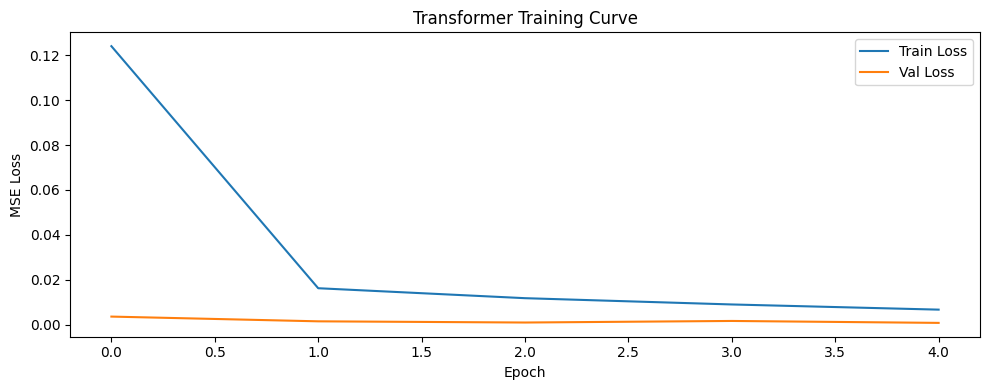

In [35]:
# Plot Transformer training curves
plt.figure(figsize=(10, 4))
plt.plot(transformer_train_losses[:5], label="Train Loss")
plt.plot(transformer_val_losses[:5],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("transformer_training_curve.png", dpi=100)
plt.show()

In [36]:
# Evaluate Transformer on test set
transformer_model.eval()
with torch.no_grad():
    transformer_preds = transformer_model(X_test_t).numpy()

transformer_mae = np.mean(np.abs(transformer_preds - y_test))
print(f"Transformer Test MAE: {transformer_mae:.6f}")

Transformer Test MAE: 0.013530


---
## Section 6: Model Comparison

We compare LSTM vs Transformer on two metrics:
- **MAE** (Mean Absolute Error): average prediction error on test set
- **Naive baseline**: always predict return = 0 (simplest possible model)

If both models beat the naive baseline, they are learning something meaningful.

Naive Baseline MAE:  0.012311
LSTM MAE:            0.012670
Transformer MAE:     0.013530


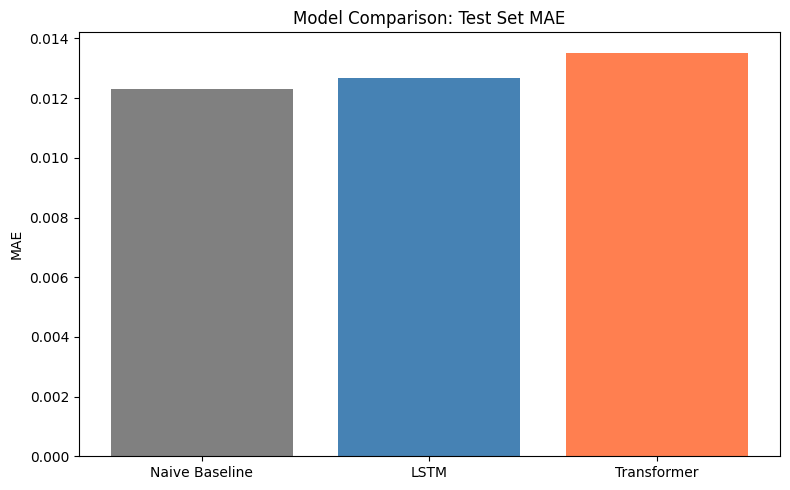

In [37]:
# Naive baseline: always predict 0 return
naive_preds = np.zeros_like(y_test)
naive_mae   = np.mean(np.abs(naive_preds - y_test))

print("=" * 40)
print(f"Naive Baseline MAE:  {naive_mae:.6f}")
print(f"LSTM MAE:            {lstm_mae:.6f}")
print(f"Transformer MAE:     {transformer_mae:.6f}")
print("=" * 40)

# Bar chart comparison
models = ["Naive Baseline", "LSTM", "Transformer"]
maes   = [naive_mae, lstm_mae, transformer_mae]

plt.figure(figsize=(8, 5))
plt.bar(models, maes, color=["gray", "steelblue", "coral"])
plt.ylabel("MAE")
plt.title("Model Comparison: Test Set MAE")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100)
plt.show()

---
## Section 7: Backtesting & Portfolio Simulation

We translate model predictions into trading signals and simulate portfolio performance.

**Trading logic (simple long-only strategy):**
- If predicted return > 0 → buy (signal = 1)
- If predicted return ≤ 0 → stay in cash (signal = 0)

**Evaluation:**
- Plot cumulative returns of model strategy vs buy & hold
- A good model should outperform buy & hold — but even if it doesn't, that is an honest and meaningful finding

=== LSTM Backtest ===
TSLA: Strategy 1.142x | Buy & Hold 1.090x
JPM: Strategy 1.135x | Buy & Hold 1.156x
XOM: Strategy 1.140x | Buy & Hold 1.190x
SPY: Strategy 1.419x | Buy & Hold 1.449x


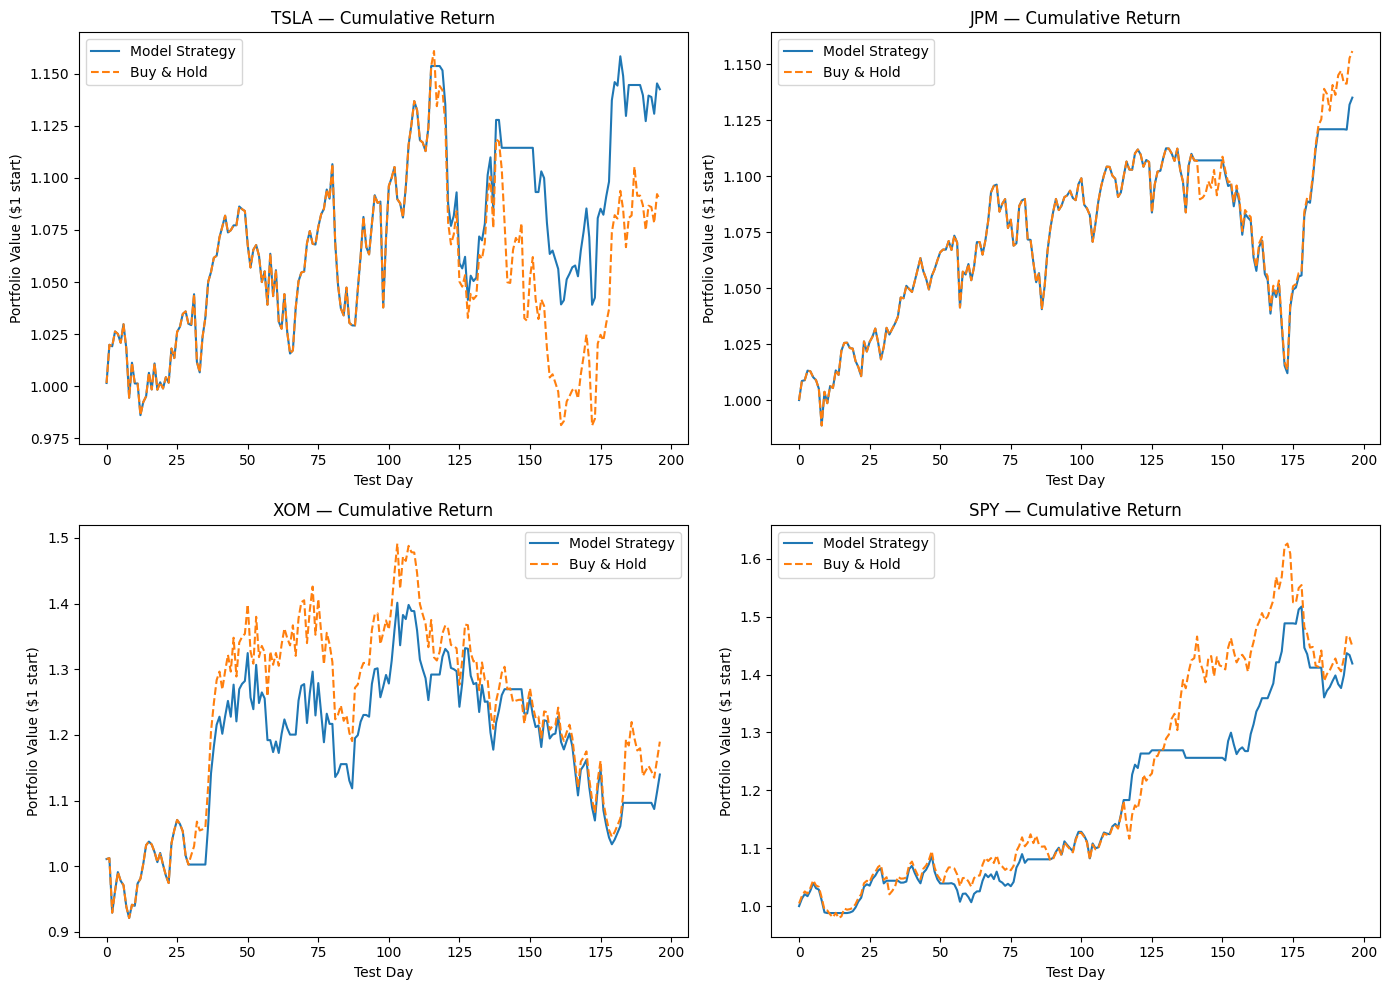

In [38]:
def backtest(preds, actual_returns, ticker_names):
    """
    Simple long-only backtest per asset.
    Signal = 1 if predicted return > 0, else 0.
    Strategy return = signal * actual return.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, ticker in enumerate(ticker_names):
        signal          = (preds[:, i] > 0).astype(float)
        strategy_return = signal * actual_returns[:, i]
        buyhold_return  = actual_returns[:, i]

        # Cumulative returns starting from $1
        cum_strategy = (1 + strategy_return).cumprod()
        cum_buyhold  = (1 + buyhold_return).cumprod()

        axes[i].plot(cum_strategy, label="Model Strategy", linewidth=1.5)
        axes[i].plot(cum_buyhold,  label="Buy & Hold",     linewidth=1.5, linestyle="--")
        axes[i].set_title(f"{ticker} — Cumulative Return")
        axes[i].set_xlabel("Test Day")
        axes[i].set_ylabel("Portfolio Value ($1 start)")
        axes[i].legend()

        final_strategy = cum_strategy.iloc[-1] if hasattr(cum_strategy, 'iloc') else cum_strategy[-1]
        final_buyhold  = cum_buyhold.iloc[-1]  if hasattr(cum_buyhold,  'iloc') else cum_buyhold[-1]
        print(f"{ticker}: Strategy {final_strategy:.3f}x | Buy & Hold {final_buyhold:.3f}x")

    plt.tight_layout()
    plt.savefig("backtesting_results.png", dpi=100)
    plt.show()


print("=== LSTM Backtest ===")
backtest(lstm_preds, y_test, TICKERS)

---
## Section 8: Results & Reflection

put this as baseline and add more technical indicators to compare, also could pull data from different packages to compare, also could try different window sizes to see how it affects the performance. since the training part is pretty fast.